In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, make_scorer

In [2]:
icustays = pd.read_feather("../data/processed/icustays_20240602.feather")
icutabular = pd.read_feather("../data/processed/icu_tabular_features_0M_0ed859c799267d4ae737f8814d52726d_20240602.feather")

df_icu = pd.merge(icustays, icutabular, on='subject_id')

columns_to_drop = ['subject_id', 'hadm_id_x', 'icu_stay_id', 'icu_intime', 'icu_outtime', 'stay_is_readmission', 'hadm_id_y', 'stay_id']
df_icu = df_icu.drop(columns=columns_to_drop)

df_icu['will_be_readmitted'] = df_icu['will_be_readmitted'].astype(int)
df_icu['first_careunit'] = df_icu['first_careunit'].astype('category').cat.codes

columns_to_fillna = df_icu.columns[df_icu.isna().any()].tolist()
df_icu[columns_to_fillna] = df_icu[columns_to_fillna].fillna(df_icu[columns_to_fillna].mean())

df_icu

,first_careunit,icu_los,hours_until_readmission,will_be_readmitted,hours_to_readmission,Arterial Blood Pressure diastolic_max,Arterial Blood Pressure diastolic_mean,Arterial Blood Pressure diastolic_min,Arterial Blood Pressure diastolic_std,Arterial Blood Pressure mean_max,...,pO2_median,pO2_min,pO2_std,urine_last_1d,anchor_age,is_planed,is_surg,aids,neoplasie,metastatic_cancer
0,2,0.410266,203.378953,0,205.318063,76.708333,58.899239,46.347222,7.631498,109.5,...,124.771654,90.897638,52.51694,175.000000,52.0,False,False,1.0,1.0,1.0
1,2,0.497535,203.378953,0,205.318063,76.708333,58.899239,46.347222,7.631498,109.5,...,124.771654,90.897638,52.51694,1820.263636,73.0,False,False,1.0,1.0,1.0
2,7,1.118032,665.573333,1,205.318063,76.708333,58.899239,46.347222,7.631498,109.5,...,124.771654,90.897638,52.51694,2645.000000,55.0,False,True,1.0,1.0,1.0
3,7,1.118032,665.573333,1,205.318063,76.708333,58.899239,46.347222,7.631498,109.5,...,124.771654,90.897638,52.51694,2475.000000,55.0,False,True,1.0,1.0,1.0
4,7,0.948113,203.378953,0,665.573333,76.708333,58.899239,46.347222,7.631498,109.5,...,124.771654,90.897638,52.51694,2645.000000,55.0,False,True,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158411,7,6.950370,203.378953,0,205.318063,76.708333,58.899239,46.347222,7.631498,109.5,...,124.771654,90.897638,52.51694,1820.263636,41.0,True,True,1.0,1.0,1.0
158412,3,0.960741,203.378953,0,205.318063,76.708333,58.899239,46.347222,7.631498,109.5,...,124.771654,90.897638,52.51694,1820.263636,81.0,False,False,1.0,1.0,1.0
158413,2,1.790995,203.378953,0,205.318063,76.708333,58.899239,46.347222,7.631498,109.5,...,124.771654,90.897638,52.51694,1820.263636,46.0,False,False,1.0,1.0,1.0
158414,8,5.297766,203.378953,0,205.318063,76.708333,58.899239,46.347222,7.631498,109.5,...,124.771654,90.897638,52.51694,1820.263636,58.0,False,False,1.0,1.0,1.0


Feature Importance

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Tidal Volume (set)_std: -0.0016529965352314396
Tidal Volume (observed)_max: -0.0016673161408178319
Non Invasive Blood Pressure mean_max: 0.0017153290910003637
H_max: 0.0017250937097079682
Glucose_max: -0.001785256391170538
H_median: 0.0018090566335606118
is_planed: -0.0018374571044675481
Non Invasive Blood Pressure diastolic_max: 0.001898348035905455
Tidal Volume (spontaneous)_min: -0.0019523194734211268
Glucose finger stick (range 70-100)_min: 0.001977113377932057
Asparate Aminotransferase (AST)_std: 0.0020073966347977893
Non Invasive Blood Pressure systolic_max: 0.0021323045670155693
pO2_std: -0.0021491049499719832
Tidal Volume (set)_max: -0.0021556350957130706
pO2_min: 0.002241353216790034
Tidal Volume (observed)_min: -0.0023628302094560473
Glucose finger stick (range 70-100)_median: 0.002916230180931861
Tidal Volume (observed)_mean: -0.002922482342415125
pO2_max: -0.003218613945403636
Glucose_min: 0.003910072313157371
Glucose_median: 0.003934198027886744
first_careunit: 0.004180363

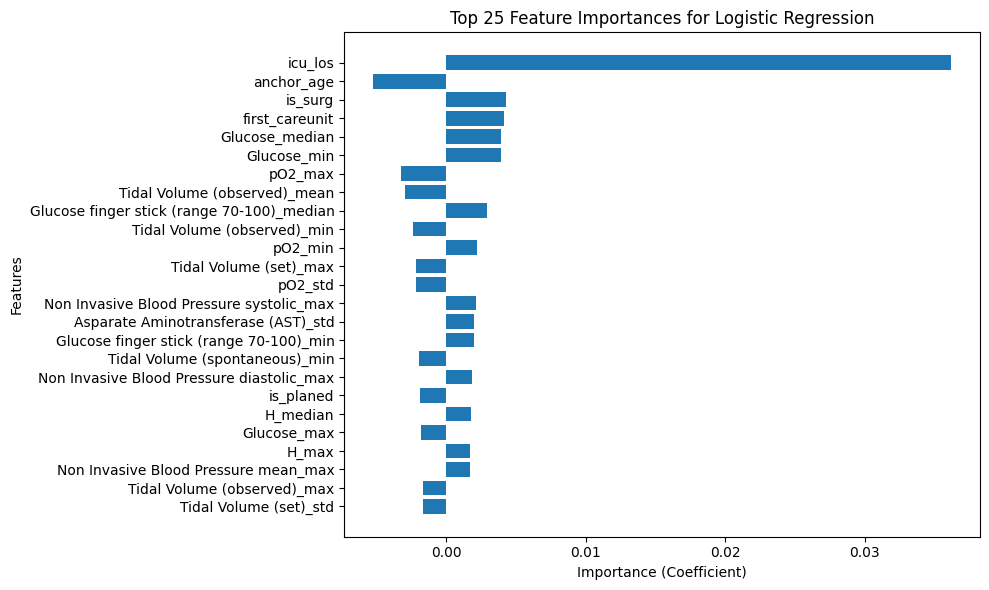

In [3]:
# Split data into features (X) and target variable (y)
X = df_icu.drop(columns=['will_be_readmitted'])
y = df_icu['will_be_readmitted']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize LogisticRegression
clf = LogisticRegression(random_state=42)

# Train the classifier
clf.fit(X_train, y_train)

# Get feature coefficients (importances for logistic regression)
feature_importances = clf.coef_[0]

# Get absolute values of the coefficients for ranking
abs_importances = np.abs(feature_importances)

# Get indices of the top 25 features
top_25_indices = np.argsort(abs_importances)[-25:]

# Get the top 25 features and their importances
top_25_features = X.columns[top_25_indices]
top_25_importances = feature_importances[top_25_indices]

# Print the top 25 feature importances
for feature_name, importance in zip(top_25_features, top_25_importances):
    print(f"{feature_name}: {importance}")

# Plot the top 25 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_25_features, top_25_importances)
plt.xlabel('Importance (Coefficient)')
plt.ylabel('Features')
plt.title('Top 25 Feature Importances for Logistic Regression')
plt.tight_layout()
plt.show()


Logistic Regression

In [7]:
# Initialize logistic regression model
logreg = LogisticRegression(random_state=42)
# alpha parameter

logreg.fit(X_train, y_train)

# Predict on test data
y_pred = logreg.predict(X_test)

# Print classification report and confusion matrix
roc_auc = roc_auc_score(y_test, y_pred)
print(f'ROC AUC Score: {roc_auc}')

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC AUC Score: 0.5000440491285647
Accuracy: 0.7530930438076
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     23863
           1       0.33      0.00      0.00      7821

    accuracy                           0.75     31684
   macro avg       0.54      0.50      0.43     31684
weighted avg       0.65      0.75      0.65     31684

Confusion Matrix:
[[23859     4]
 [ 7819     2]]


Balancing datset with class_weight='balanced'

In [5]:
# Initialize logistic regression model with balanced class weights
logreg = LogisticRegression(random_state=42, class_weight='balanced')

# Train the model
logreg.fit(X_train, y_train)

# Predict on test data
y_pred = logreg.predict(X_test)

# Print classification report and confusion matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.5477212473172579
              precision    recall  f1-score   support

           0       0.77      0.57      0.65     23863
           1       0.27      0.49      0.35      7821

    accuracy                           0.55     31684
   macro avg       0.52      0.53      0.50     31684
weighted avg       0.65      0.55      0.58     31684

Confusion Matrix:
[[13557 10306]
 [ 4024  3797]]


Lasso

In [6]:
# Initialize logistic regression model with balanced class weights and Lasso regularization
logreg = LogisticRegression(random_state=42, class_weight='balanced', penalty='l1', solver='liblinear')

# Train the model
logreg.fit(X_train, y_train)

# Predict on test data
y_pred = logreg.predict(X_test)

# Print classification report and confusion matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy: 0.540809241257417
              precision    recall  f1-score   support

           0       0.78      0.55      0.64     23863
           1       0.27      0.52      0.36      7821

    accuracy                           0.54     31684
   macro avg       0.52      0.53      0.50     31684
weighted avg       0.65      0.54      0.57     31684

Confusion Matrix:
[[13079 10784]
 [ 3765  4056]]
